<a href="https://colab.research.google.com/github/aniilkeles/DeepLearningNotes/blob/main/Pytorch_MulticlassClassification_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [24]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [25]:
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [26]:
df = pd.read_csv('/content/drive/MyDrive/Dataset/09-iris.csv')

In [27]:
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [29]:
df.Species.value_counts()

,count
Species,
Iris-setosa,50
Iris-versicolor,50
Iris-virginica,50


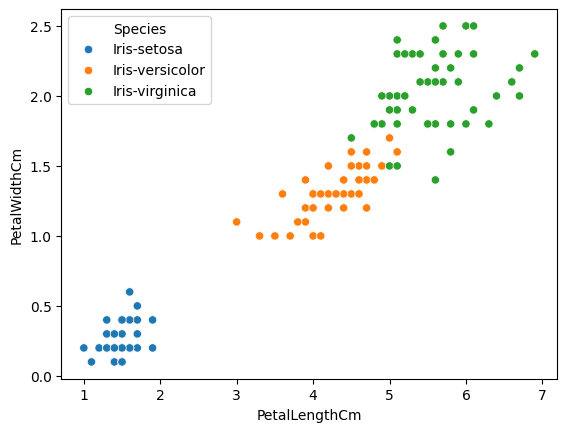

In [30]:
sns.scatterplot(x=df['PetalLengthCm'],y=df['PetalWidthCm'],hue=df['Species'])
plt.show()

In [31]:
df = df.drop('Id',axis=1)

In [32]:
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [33]:
X = df[['SepalLengthCm','SepalWidthCm','PetalLengthCm','PetalWidthCm']].values
y = df['Species'].values

In [34]:
y

array(['Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa',
       'Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa',
       'Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa',
       'Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa',
       'Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa',
       'Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa',
       'Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa',
       'Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa',
       'Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa',
       'Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa',
       'Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa',
       'Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa',
       'Iris-setosa', 'Iris-setosa', 'Iris-versicolor', 'Iris-versicolor',
       'Iris-versicolor', 'Iris-versicolor', 'Iris-versicolor',
       'Iris-versicolor', 'Iris-versicolor', 'Iris-versic

In [35]:
# label encoding

In [36]:
from sklearn.preprocessing import LabelEncoder

In [37]:
le = LabelEncoder()
y = le.fit_transform(y)

In [38]:
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [39]:
from sklearn.model_selection import train_test_split

X_train , X_test , y_train , y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [40]:
y_test

array([0, 2, 1, 1, 0, 1, 0, 0, 2, 1, 2, 2, 2, 1, 0, 0, 0, 1, 1, 2, 0, 2,
       1, 2, 2, 1, 1, 0, 2, 0])

In [41]:
X_train=torch.tensor(X_train,dtype = torch.float32)
X_test = torch.tensor(X_test,dtype = torch.float32)

y_train = torch.tensor(y_train,dtype = torch.long)
y_test = torch.tensor(y_test,dtype = torch.long) # multi class olunca y_train ve y_test dtype long olmak zorunda

In [42]:
print(X_train.shape,X_test.shape)
print(y_train.shape,y_test.shape)
# binary cross entropy de inputla output size aynı olmak zorundaydı ama cross entropy de boyutun bir önemi yok

torch.Size([120, 4]) torch.Size([30, 4])
torch.Size([120]) torch.Size([30])


In [43]:
# from torch import nn

# class IrisClassifier(nn.Module):
#   def __init__(self):
#     super().__init__()

#     self.layer1 = nn.Linear(in_features=4,out_features=16)
#     self.layer2 = nn.Linear(in_features=16,out_features=16)
#     self.layer3 = nn.Linear(in_features=16,out_features=3)

#     self.relu = nn.ReLU()

#   def forward(self,x):
#     return self.layer3(self.relu(self.layer2(self.relu(self.layer1(x)))))

In [44]:
# yukarıdaki kodla bu kod bloğu aynıdır.Daha çok tercih edilir bu kod bloğu kolaylık açısından.
from torch import nn

class IrisClassifier(nn.Module):
  def __init__(self):
    super().__init__()

    # sequential içerisinde birsürü layer barındıran mimarilerde sırasıyla kullan anlamına gelir.
    self.linear_layer_stack = nn.Sequential(

              nn.Linear(4,16),
              nn.ReLU(),
              nn.Linear(16,16),
              nn.ReLU(),
              nn.Linear(16,3)

    )

  def forward(self,x):
    return self.linear_layer_stack(x)

In [76]:
model = IrisClassifier()

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model.parameters(),lr=0.01)

In [77]:
def calculate_accuracy(y_test,y_pred):
  correct = torch.eq(y_test,y_pred).sum().item()
  acc = (correct / len(y_pred)) * 100
  return acc

In [78]:
model(X_test)[:5] # logitler bunlar olasılık değil bizim olasılığa çevirmemiz gerekecek.

tensor([[-0.0897, -0.1535,  0.0426],
        [-0.1254, -0.5414, -0.0226],
        [-0.1143, -0.3542,  0.0072],
        [-0.1158, -0.3668,  0.0073],
        [-0.0842, -0.1312,  0.0426]], grad_fn=<SliceBackward0>)

In [79]:
model(X_test)[0].shape

torch.Size([3])

In [80]:
y_logits = model(X_test)

In [81]:
y_pred_probs = torch.softmax(y_logits,dim=1) # dim 1 dediğimizde bütün boyutlardaki bütün olasıklar alınır.

In [82]:
y_logits[:5]

tensor([[-0.0897, -0.1535,  0.0426],
        [-0.1254, -0.5414, -0.0226],
        [-0.1143, -0.3542,  0.0072],
        [-0.1158, -0.3668,  0.0073],
        [-0.0842, -0.1312,  0.0426]], grad_fn=<SliceBackward0>)

In [83]:
y_pred_probs[:5] # olasılığa çevrilmiş halleri

tensor([[0.3247, 0.3046, 0.3706],
        [0.3613, 0.2383, 0.4004],
        [0.3430, 0.2698, 0.3873],
        [0.3438, 0.2675, 0.3888],
        [0.3237, 0.3088, 0.3675]], grad_fn=<SliceBackward0>)

In [84]:
torch.argmax(y_pred_probs[0]) # bu bize en yüksek olasılığı döndürecek mesela burdan anlıyoruzki ilk data 2.sınıfa aitmiş diye yorumda bulunabiliriz.

tensor(2)

In [85]:
torch.softmax(y_logits,dim=1).argmax(dim=1) # bu şekilde hangi sınıfa ait olduğunu bulabileceğiz.

tensor([2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
        2, 2, 2, 2, 2, 2])

In [86]:
epochs = 200

train_losses = []
test_losses = []
train_accuracies = []
test_accuracies = []

for epoch in range(epochs):
  model.train()
  logits = model(X_train)
  loss = loss_fn(logits,y_train)

  pred = torch.softmax(logits,dim=1).argmax(dim=1)
  acc = calculate_accuracy(y_train,pred)

  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  train_losses.append(loss.item())
  train_accuracies.append(acc)

  model.eval()
  with torch.inference_mode():
    test_logits = model(X_test)
    test_loss = loss_fn(test_logits,y_test)
    test_pred = torch.softmax(test_logits,dim=1).argmax(dim=1)
    test_acc = calculate_accuracy(y_test,test_pred)

  test_losses.append(test_loss.item())
  test_accuracies.append(test_acc)

  if epoch % 20 == 0:
    print(f"Epoch : {epoch} , Loss : {loss} , Accuracy : {acc} , Test Loss : {test_loss} , Test Accuracy : {test_acc}")

Epoch : 0 , Loss : 1.1313368082046509 , Accuracy : 33.33333333333333 , Test Loss : 1.0767056941986084 , Test Accuracy : 63.33333333333333
Epoch : 20 , Loss : 0.3484812378883362 , Accuracy : 96.66666666666667 , Test Loss : 0.32860273122787476 , Test Accuracy : 96.66666666666667
Epoch : 40 , Loss : 0.08203102648258209 , Accuracy : 98.33333333333333 , Test Loss : 0.08213873952627182 , Test Accuracy : 100.0
Epoch : 60 , Loss : 0.05785653740167618 , Accuracy : 98.33333333333333 , Test Loss : 0.04902411624789238 , Test Accuracy : 100.0
Epoch : 80 , Loss : 0.05385125055909157 , Accuracy : 98.33333333333333 , Test Loss : 0.04291879013180733 , Test Accuracy : 100.0
Epoch : 100 , Loss : 0.051307644695043564 , Accuracy : 98.33333333333333 , Test Loss : 0.04216074198484421 , Test Accuracy : 100.0
Epoch : 120 , Loss : 0.049933262169361115 , Accuracy : 98.33333333333333 , Test Loss : 0.05410633608698845 , Test Accuracy : 96.66666666666667
Epoch : 140 , Loss : 0.047695621848106384 , Accuracy : 98.333

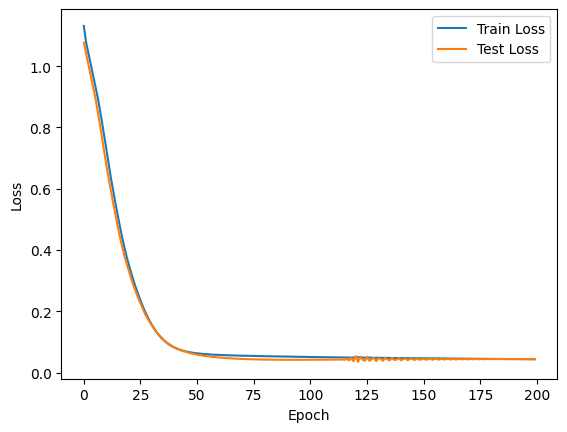

In [87]:
plt.plot(train_losses,label="Train Loss")
plt.plot(test_losses,label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

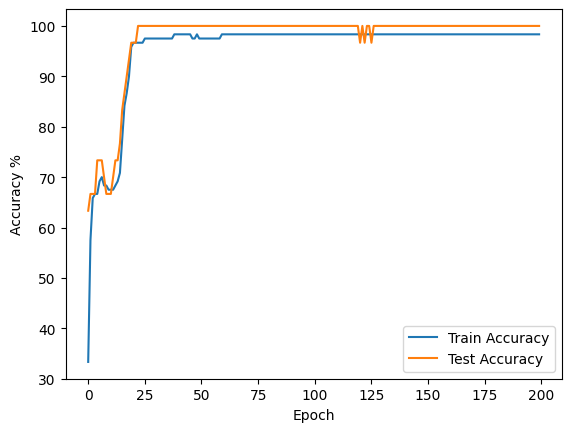

In [88]:
plt.plot(train_accuracies,label="Train Accuracy")
plt.plot(test_accuracies,label="Test Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy %")
plt.legend()
plt.show()

In [89]:
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [90]:
new_sample = np.array([[5.1,3.5,1.4,0.2]])

In [91]:
new_sample_tensor = torch.tensor(new_sample,dtype = torch.float32)

In [92]:
new_sample.shape

(1, 4)

In [93]:
model.eval()
with torch.inference_mode():
  logits = model(new_sample_tensor)
  probs = torch.softmax(logits,dim=1)
  predicted_class = torch.argmax(probs,dim=1).item()

In [94]:
predicted_class

0

In [98]:
le.inverse_transform([predicted_class])[0]

'Iris-setosa'

In [99]:
# torch metrics

In [100]:
!pip install torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 14.7 MB/s eta 0:00:00


In [101]:
from torchmetrics.classification import MulticlassAccuracy

In [103]:
accuracy = MulticlassAccuracy(num_classes = 3)

In [104]:
epochs = 200

model2 = IrisClassifier()
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model2.parameters(),lr=0.01)

for epoch in range(epochs):
  model2.train()

  logits = model2(X_train)
  loss = loss_fn(logits,y_train)

  pred = torch.softmax(logits,dim=1).argmax(dim=1)

  acc = accuracy(pred,y_train).item() * 100

  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  model.eval()

  with torch.inference_mode():
    test_logits = model2(X_test)
    test_loss = loss_fn(test_logits,y_test)

    test_pred = torch.softmax(test_logits,dim=1).argmax(dim=1)

    test_acc = accuracy(test_pred,y_test).item() * 100

  if epoch % 20 == 0:
    print(f"Epoch : {epoch} , Loss : {loss} , Accuracy : {acc} , Test Loss : {test_loss} , Test Accuracy : {test_acc}")

Epoch : 0 , Loss : 1.1400017738342285 , Accuracy : 33.33333432674408 , Test Loss : 1.0810835361480713 , Test Accuracy : 33.33333432674408
Epoch : 20 , Loss : 0.3983520269393921 , Accuracy : 93.33333969116211 , Test Loss : 0.38389918208122253 , Test Accuracy : 93.33333969116211
Epoch : 40 , Loss : 0.09930562973022461 , Accuracy : 97.50000238418579 , Test Loss : 0.09512736648321152 , Test Accuracy : 100.0
Epoch : 60 , Loss : 0.06375735998153687 , Accuracy : 97.50000238418579 , Test Loss : 0.04811229556798935 , Test Accuracy : 100.0
Epoch : 80 , Loss : 0.057982441037893295 , Accuracy : 98.33333492279053 , Test Loss : 0.0417456291615963 , Test Accuracy : 100.0
Epoch : 100 , Loss : 0.054875459522008896 , Accuracy : 98.33333492279053 , Test Loss : 0.03965931013226509 , Test Accuracy : 100.0
Epoch : 120 , Loss : 0.05270081385970116 , Accuracy : 98.33333492279053 , Test Loss : 0.04064156860113144 , Test Accuracy : 100.0
Epoch : 140 , Loss : 0.0508236400783062 , Accuracy : 98.33333492279053 , T

In [105]:
from torchmetrics.classification import MulticlassConfusionMatrix

In [106]:
cm = MulticlassConfusionMatrix(num_classes=3)
matrix = cm(test_pred,y_test)

In [107]:
matrix

tensor([[10,  0,  0],
        [ 0, 10,  0],
        [ 0,  0, 10]])

In [108]:
from torchmetrics.utilities.plot import plot_confusion_matrix

(<Figure size 640x480 with 1 Axes>,
 <Axes: xlabel='Predicted class', ylabel='True class'>)

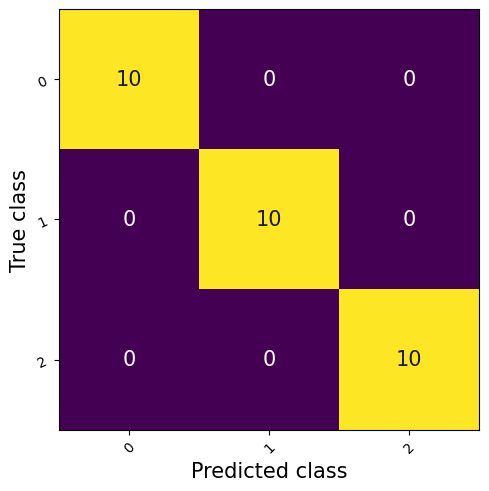

In [109]:
plot_confusion_matrix(matrix)